In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.utils import to_categorical

In [ ]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1294s 8us/step


In [ ]:
from matplotlib import font_manager as fm
import os
import numpy as np
import pandas as pd

In [ ]:
font_path = "times.ttf"  # Path to the font file on root

if os.path.exists(font_path):
    # Add the file to Matplotlib's internal font registry
    fm.fontManager.addfont(font_path)
    # Extract the precise font family name from the file
    prop = fm.FontProperties(fname=font_path)

    # Apply globally to Matplotlib
    plt.rcParams["font.family"] = prop.get_name()
    plt.rcParams["font.weight"] = "bold"
    plt.rcParams["axes.labelweight"] = "bold"
    plt.rcParams["axes.titleweight"] = "bold"
else:
    print(f"Warning: {font_path} not found. Using default font.")

In [ ]:
X_train.shape

(50000, 32, 32, 3)

In [ ]:
X_test.shape

(10000, 32, 32, 3)

In [ ]:
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
]

Image successfully saved as 'cifar10_classes_grid.eps' with 600 DPI.


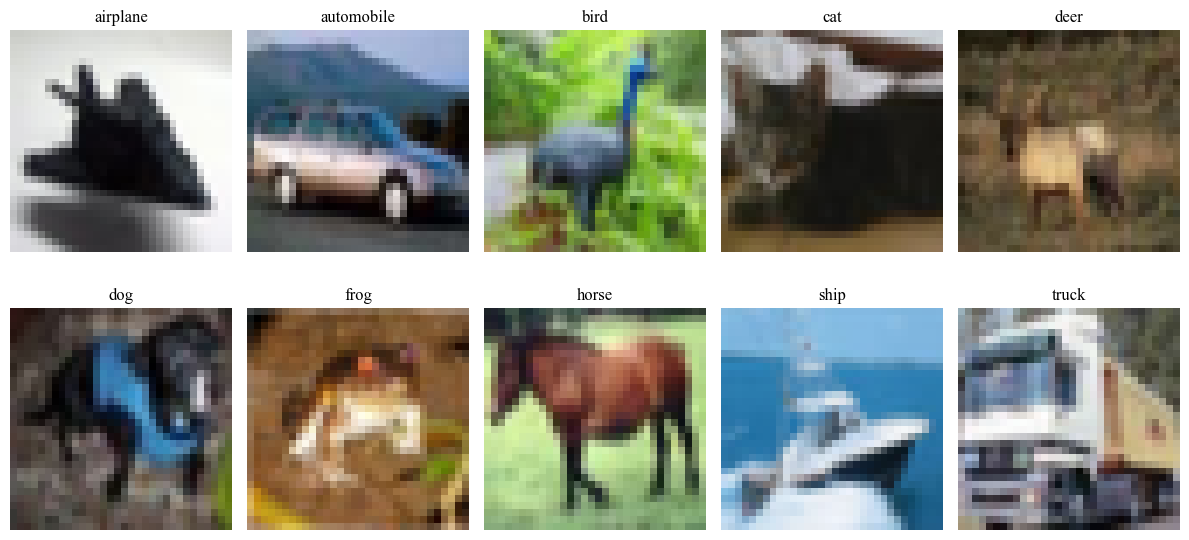

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
axes = axes.ravel()

for i in range(10):
    idx = np.where(y_train == i)[0][0]  # Get the scalar index of the first match

    axes[i].imshow(X_train[idx])
    axes[i].set_title(class_names[i], fontsize=12, fontweight="bold")
    axes[i].axis("off")

plt.tight_layout()

# 5. Save the output in EPS format at 600 DPI
# Note: EPS files do not support transparency; keep format='eps' explicitly.
plt.savefig("cifar10_classes_grid.eps", format="eps", dpi=600)
print("Image successfully saved as 'cifar10_classes_grid.eps' with 600 DPI.")

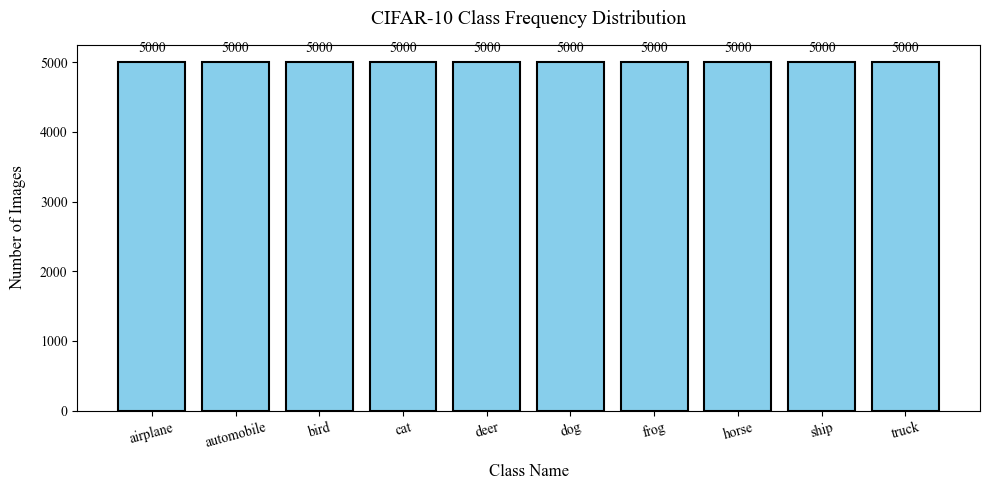

In [ ]:

classes, counts = np.unique(y_train, return_counts=True)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(class_names, counts, color="skyblue", edgecolor="black", linewidth=1.5)

for bar in bars:
    yval = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2.0,
        yval + 100,
        f"{yval}",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

# 5. Label axes and title
ax.set_title("CIFAR-10 Class Frequency Distribution", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Class Name", fontsize=12, fontweight="bold", labelpad=10)
ax.set_ylabel("Number of Images", fontsize=12, fontweight="bold", labelpad=10)

plt.xticks(rotation=15, fontweight="bold")
plt.yticks(fontweight="bold")
plt.tight_layout()

# 6. Save the output in EPS format at 600 DPI
plt.savefig("cifar10_frequency_distribution.eps", format="eps", dpi=600)
plt.show()

In [ ]:
mean = X_train.mean(axis=(0, 1, 2))
std = X_train.std(axis=(0, 1, 2))

x_train_standardized = (X_train - mean) / std
x_test_standardized = (X_train - mean) / std

In [ ]:
y_train_encoded = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test_encoded = tf.keras.utils.to_categorical(y_test, num_classes=10)

In [ ]:
model = models.Sequential(
    [
        layers.Conv2D(32, (3, 3), activation="relu", input_shape=(32, 32, 3)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), padding = "same" , activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),

        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(10, activation="softmax")

    ]
)
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 15, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,218 (1.61 MB)

 Trainable params: 422,218 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
tf.keras.backend.clear_session()
history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=64,
    validation_split= 0.2
)

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.1702 - loss: 2.6817 - val_accuracy: 0.3368 - val_loss: 1.8005
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.3011 - loss: 1.8574 - val_accuracy: 0.4178 - val_loss: 1.6198
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3669 - loss: 1.6957 - val_accuracy: 0.4778 - val_loss: 1.4840
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4169 - loss: 1.5726 - val_accuracy: 0.5181 - val_loss: 1.3771
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4500 - loss: 1.4963 - val_accuracy: 0.5320 - val_loss: 1.3437
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4805 - loss: 1.4220 - val_accuracy: 0.5553 - val_loss: 1.2849
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5145 - loss: 1.3566 - val_accuracy: 0.5780 - val_loss: 1.2182
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5380 - loss: 1.2830 - val_accuracy: 0.

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 15, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,266,656 (4.83 MB)

 Trainable params: 422,218 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 844,438 (3.22 MB)

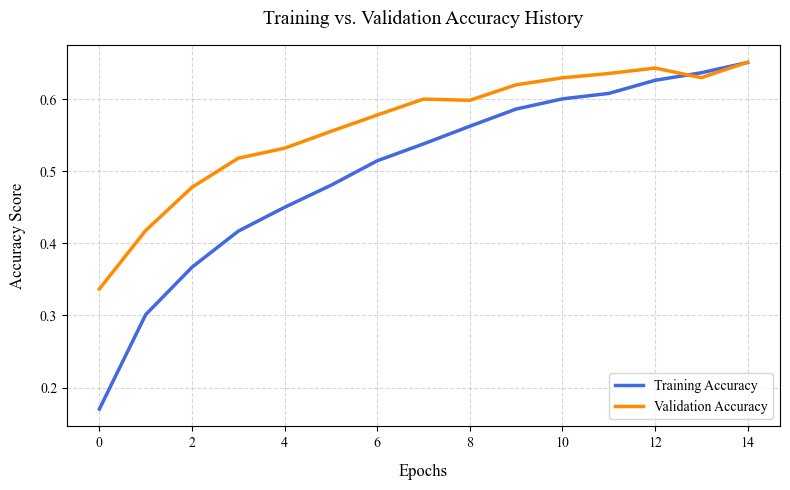

In [ ]:
plt.figure(figsize=(8, 5))

# 3. Plot the training and validation metric tracking lines
plt.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2.5, color='royalblue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2.5, color='darkorange')

# 4. Set structural markers, title, labels and bold weights
plt.title('Training vs. Validation Accuracy History', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Accuracy Score', fontsize=12, fontweight='bold', labelpad=10)

plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower right')
plt.tight_layout()

# 5. Export to Vector EPS document standard at 600 DPI
plt.savefig("cifar10_accuracy_comparison.eps", format="eps", dpi=600)
plt.show()

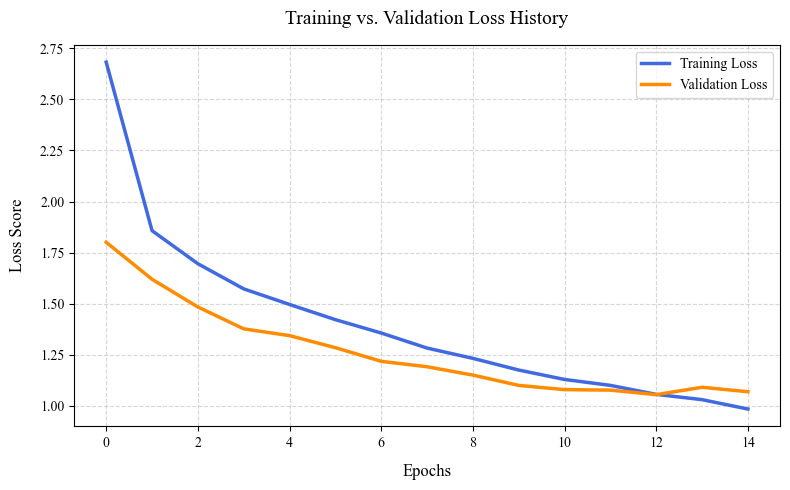

In [ ]:
plt.figure(figsize=(8, 5))

# 3. Plot the training and validation loss tracking lines
plt.plot(history.history['loss'], label='Training Loss', linewidth=2.5, color='royalblue')
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2.5, color='darkorange')

# 4. Set structural markers, title, labels and bold weights
plt.title('Training vs. Validation Loss History', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Loss Score', fontsize=12, fontweight='bold', labelpad=10)

plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')
plt.tight_layout()

# 5. Export to Vector EPS document standard at 600 DPI
plt.savefig("cifar10_loss_comparison.eps", format="eps", dpi=600)
plt.show()

In [ ]:

from sklearn.metrics import classification_report, confusion_matrix

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Ensure y_test is a flat array of integers matching y_pred
if len(y_test.shape) > 1 and y_test.shape[1] > 1:
    y_true = np.argmax(y_test, axis=1)  # If one-hot encoded
else:
    y_true = y_test.flatten()  # If integer labels



313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [ ]:
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print(report)

              precision    recall  f1-score   support

    airplane     0.6763    0.7290    0.7016      1000
  automobile     0.7937    0.7850    0.7893      1000
        bird     0.4852    0.5890    0.5321      1000
         cat     0.4426    0.4470    0.4448      1000
        deer     0.5978    0.4890    0.5380      1000
         dog     0.5970    0.4740    0.5284      1000
        frog     0.7834    0.6870    0.7320      1000
       horse     0.7210    0.7080    0.7144      1000
        ship     0.7581    0.7960    0.7766      1000
       truck     0.6524    0.7750    0.7084      1000

    accuracy                         0.6479     10000
   macro avg     0.6507    0.6479    0.6466     10000
weighted avg     0.6507    0.6479    0.6466     10000



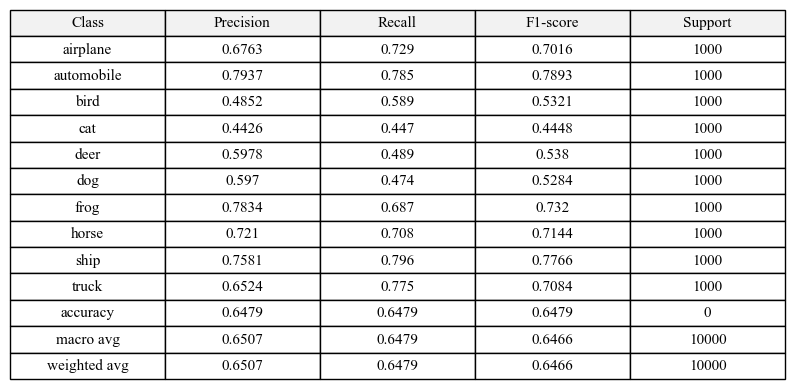

Successfully generated and saved 'cifar10_table_metrics.eps'.


In [ ]:
report_dict = classification_report(
    y_true, y_pred,
    target_names=class_names,
    digits=4,
    output_dict=True
)
df = pd.DataFrame(report_dict).transpose().round(4)
df["support"] = df["support"].astype(int)

# Format the row/column structures for presentation
df.index.name = "Class"
df = df.reset_index()
columns = [col.capitalize() for col in df.columns]
cell_text = df.values
fig, ax = plt.subplots(figsize=(8, 4))
ax.axis("off")  # Turn off standard chart axes lines

# 4. Generate the structured Matplotlib data table
table = ax.table(
    cellText=cell_text,
    colLabels=columns,
    loc="center",
    cellLoc="center"
)

# 5. Format table styling constraints to enforce strict bold typography
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.6)  # Add padding to cell boundaries

for (row, col), cell in table.get_celld().items():
    cell.set_text_props(fontweight="bold")  # Apply bold weights to headers and data cells
    if row == 0:
        cell.set_facecolor("#f2f2f2")  # Light gray background background accent for headings

plt.tight_layout()

# 6. Save the text metrics table structure as an EPS file at 600 DPI
plt.savefig("cifar10_table_metrics.eps", format="eps", dpi=600)
plt.show()
print("Successfully generated and saved 'cifar10_table_metrics.eps'.")

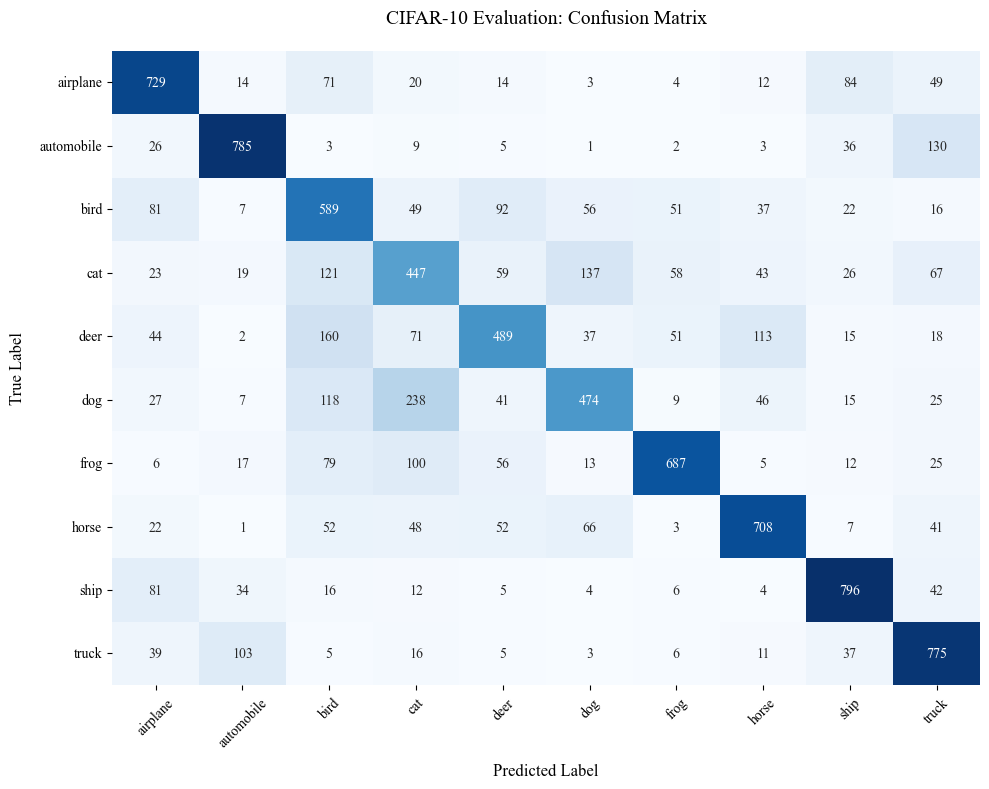

In [ ]:
cm = confusion_matrix(y_true, y_pred)

# 5. Plot the Confusion Matrix Map
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=False,
    annot_kws={"weight": "bold", "size": 10}
)

# 6. Apply structural labels and bold layouts
plt.title("CIFAR-10 Evaluation: Confusion Matrix", fontsize=14, fontweight="bold", pad=20)
plt.xlabel("Predicted Label", fontsize=12, fontweight="bold", labelpad=10)
plt.ylabel("True Label", fontsize=12, fontweight="bold", labelpad=10)

plt.xticks(rotation=45, fontweight="bold")
plt.yticks(rotation=0, fontweight="bold")
plt.tight_layout()

# 7. Save output as high-resolution Vector EPS standard at 600 DPI
plt.savefig("cifar10_evaluation_metrics.eps", format="eps", dpi=600)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 649ms/step


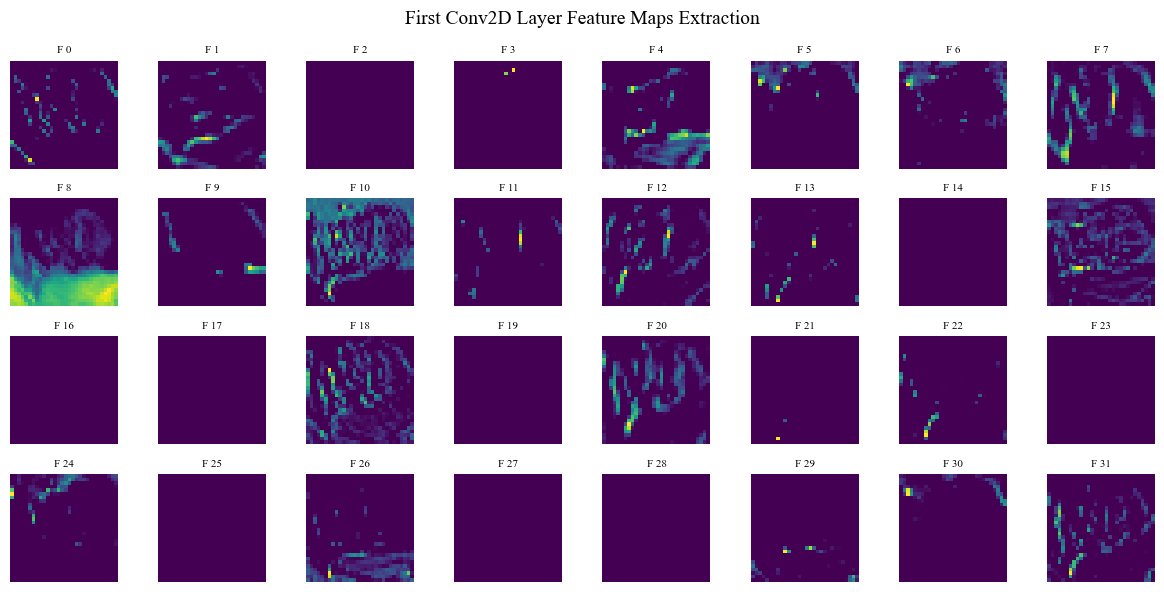

In [ ]:
test_image = X_test[0]  # Shape: (32, 32, 3)
# Expand dimensions to create a batch of 1: shape (1, 32, 32, 3)
input_tensor = np.expand_dims(test_image, axis=0)

# 2. Extract layers to inspect (all Conv2D layers in your sequential model)
# If your model layers are indexed differently, check model.summary()
conv_layers = [layer.output for layer in model.layers if isinstance(layer, tf.keras.layers.Conv2D)]

# 3. Create a multi-output visualization model using the functional API
activation_model = tf.keras.models.Model(inputs=model.layers[0].input, outputs=conv_layers)

# 4. Pass the single image through the network to extract feature maps
feature_maps = activation_model.predict(input_tensor)

# Ensure feature_maps is treated as a list even if there is only 1 Conv2D layer
if not isinstance(feature_maps, list):
    feature_maps = [feature_maps]

# 5. Configure your custom Times New Roman bold font for titles
font_path = "/times.ttf"
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    prop = fm.FontProperties(fname=font_path)
    plt.rcParams["font.family"] = prop.get_name()
    plt.rcParams["font.weight"] = "bold"
    plt.rcParams["axes.titleweight"] = "bold"

# 6. Plot the feature maps for the first Conv2D layer (e.g., 32 filters)
# Change the index feature_maps[0] to feature_maps[1] to view the second Conv layer
first_layer_features = feature_maps[0]  # Shape: (1, height, width, 32)
num_filters = first_layer_features.shape[-1]

# Set up a grid layout (e.g., 4 rows by 8 columns for 32 filters)
fig, axes = plt.subplots(4, 8, figsize=(12, 6))
axes = axes.ravel()

for i in range(num_filters):
    # Extract the 2D feature map matrix for the i-th filter channel
    f_map = first_layer_features[0, :, :, i]

    # Plot using a grayscale or 'viridis' colormap
    axes[i].imshow(f_map, cmap="viridis")
    axes[i].set_title(f"F {i}", fontsize=8, fontweight="bold")
    axes[i].axis("off")

plt.suptitle("First Conv2D Layer Feature Maps Extraction", fontsize=14, fontweight="bold", y=0.98)
plt.tight_layout()

# 7. Save output as a high-resolution Vector EPS standard at 600 DPI
plt.savefig("cifar10_feature_maps.eps", format="eps", dpi=600)
plt.show()

In [ ]:
import time
# 1. Load and process CIFAR-10 data cleanly
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

baseline = {
    "kernel": (3, 3),
    "filters": 32,      # Fixed the missing default filter value
    "padding": "same",
    "stride": (1, 1),
    "pooling": "max",
    "optimizer": "adam",
    "epochs": 10,
    "batch_size": 64
}

# 2. Corrected experiments list with explicit filter values
experiments = [
    {"exp_name": "Exp 1: Kernel 3x3", "changes": {"kernel": (3, 3)}},
    {"exp_name": "Exp 1: Kernel 5x5", "changes": {"kernel": (5, 5)}},

    {"exp_name": "Exp 2: Filters 32", "changes": {"filters": 32}},   # Fixed
    {"exp_name": "Exp 2: Filters 64", "changes": {"filters": 64}},   # Fixed
    {"exp_name": "Exp 2: Filters 128", "changes": {"filters": 128}}, # Fixed

    {"exp_name": "Exp 3: Padding Valid", "changes": {"padding": "valid"}},
    {"exp_name": "Exp 3: Padding Same", "changes": {"padding": "same"}},

    {"exp_name": "Exp 4: Stride 1", "changes": {"stride": (1, 1)}},
    {"exp_name": "Exp 4: Stride 2", "changes": {"stride": (2, 2)}},

    {"exp_name": "Exp 5: MaxPooling", "changes": {"pooling": "max"}},
    {"exp_name": "Exp 5: AveragePooling", "changes": {"pooling": "avg"}},

    {"exp_name": "Exp 6: Optimizer Adam", "changes": {"optimizer": "adam"}},
    {"exp_name": "Exp 6: Optimizer SGD", "changes": {"optimizer": "sgd"}},
    {"exp_name": "Exp 6: Optimizer RMSProp", "changes": {"optimizer": "rmsprop"}},

    {"exp_name": "Exp 7: Epochs 10", "changes": {"epochs": 10}},
    {"exp_name": "Exp 7: Epochs 20", "changes": {"epochs": 20}},
    {"exp_name": "Exp 7: Epochs 30", "changes": {"epochs": 30}},

    {"exp_name": "Exp 8: Batch Size 32", "changes": {"batch_size": 32}},
    {"exp_name": "Exp 8: Batch Size 64", "changes": {"batch_size": 64}},
    {"exp_name": "Exp 8: Batch Size 128", "changes": {"batch_size": 128}},
]


results_log = []

# 3. Execution Engine Loop
for run in experiments:
    print(f"\nRunning: {run['exp_name']}")

    # Merge baseline options with the specific parameter under test
    p = baseline.copy()
    p.update(run["changes"])

    tf.keras.backend.clear_session()

    # Dynamically build the model based on current loop parameters
    model = models.Sequential()
    model.add(layers.Conv2D(p["filters"], p["kernel"], padding=p["padding"], strides=p["stride"], activation="relu", input_shape=(32, 32, 3)))

    if p["pooling"] == "max":
        model.add(layers.MaxPooling2D((2, 2)))
    else:
        model.add(layers.AveragePooling2D((2, 2)))

    model.add(layers.Conv2D(p["filters"], p["kernel"], padding=p["padding"], strides=p["stride"], activation="relu"))

    if p["pooling"] == "max":
        model.add(layers.MaxPooling2D((2, 2)))
    else:
        model.add(layers.AveragePooling2D((2, 2)))

    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation="relu"))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(10, activation="softmax"))

    model.compile(optimizer=p["optimizer"], loss="sparse_categorical_crossentropy", metrics=["accuracy"])

    # Track runtime performance explicitly
    start_time = time.time()
    model.fit(X_train, y_train, epochs=p["epochs"], batch_size=p["batch_size"], validation_split=0.2, verbose=0)
    elapsed_time = time.time() - start_time

    # Evaluate score accuracy on your validation subset split
    _, val_acc = model.evaluate(X_train[40000:], y_train[40000:], verbose=0)

    # Log performance parameters
    results_log.append({
        "Experiment": run["exp_name"],
        "Accuracy": f"{val_acc * 100:.1f}%",
        "Training Time": f"{elapsed_time:.1f}s"
    })

# 4. Generate structured results DataFrame table
df_results = pd.DataFrame(results_log)
df_results.to_csv("hyperparameter_analysis_results.csv", index=False)
print("\nAll experiments complete! Results table saved.")
df_results



Running: Exp 1: Kernel 3x3

Running: Exp 1: Kernel 5x5

Running: Exp 2: Filters 32

Running: Exp 2: Filters 64

Running: Exp 2: Filters 128

Running: Exp 3: Padding Valid

Running: Exp 3: Padding Same

Running: Exp 4: Stride 1

Running: Exp 4: Stride 2

Running: Exp 5: MaxPooling

Running: Exp 5: AveragePooling

Running: Exp 6: Optimizer Adam

Running: Exp 6: Optimizer SGD

Running: Exp 6: Optimizer RMSProp

Running: Exp 7: Epochs 10

Running: Exp 7: Epochs 20

Running: Exp 7: Epochs 30

Running: Exp 8: Batch Size 32

Running: Exp 8: Batch Size 64

Running: Exp 8: Batch Size 128

All experiments complete! Results table saved.


,Experiment,Accuracy,Training Time
0,Exp 1: Kernel 3x3,67.5%,35.8s
1,Exp 1: Kernel 5x5,68.4%,38.7s
2,Exp 2: Filters 32,68.1%,32.6s
3,Exp 2: Filters 64,70.9%,40.2s
4,Exp 2: Filters 128,70.1%,63.6s
5,Exp 3: Padding Valid,66.1%,37.2s
6,Exp 3: Padding Same,68.7%,33.3s
7,Exp 4: Stride 1,68.4%,35.0s
8,Exp 4: Stride 2,56.7%,28.9s
9,Exp 5: MaxPooling,68.1%,35.9s


In [ ]:
import os
import pandas as pd

# 1. Structural Architecture Setup (Based on baseline settings)
k_w, k_h = 3, 3      # Kernel dimensions
in_ch = 3           # RGB input channels
f1 = 32             # First Conv2D filter depth
f2 = 64             # Second Conv2D filter depth

# 2. Formula Calculations
# Layer 1: (3 * 3 * 3 + 1) * 32
l1_calc = f"({k_h} $\\times$ {k_w} $\\times$ {in_ch} + 1) $\\times$ {f1}"
l1_total = (k_h * k_w * in_ch + 1) * f1

# Layer 2: (3 * 3 * 32 + 1) * 64
l2_calc = f"({k_h} $\\times$ {k_w} $\\times$ {f1} + 1) $\\times$ {f2}"
l2_total = (k_h * k_w * f1 + 1) * f2

# 3. Create DataFrame Table
param_data = {
    "Layer Name": ["First Conv Layer (conv2d_1)", "Second Conv Layer (conv2d_2)"],
    "Mathematical Formula": [l1_calc, l2_calc],
    "Total Parameters": [f"{l1_total:,}", f"{l2_total:,}"]
}
df_params = pd.DataFrame(param_data)

# 4. Export Table directly to LaTeX Source file
df_params.to_latex(
    "parameter_analysis.tex",
    index=False,
    column_format="|l|c|r|",
    escape=False, # Allows LaTeX symbols like \times to render properly
    caption="CNN Convolutional Layer Parameter Count Mathematical Analysis",
    label="tab:param_analysis"
)
print("Saved Section 12 parameters to 'parameter_analysis.tex'")
df_params


Saved Section 12 parameters to 'parameter_analysis.tex'


,Layer Name,Mathematical Formula,Total Parameters
0,First Conv Layer (conv2d_1),(3 $\times$ 3 $\times$ 3 + 1) $\times$ 32,896
1,Second Conv Layer (conv2d_2),(3 $\times$ 3 $\times$ 32 + 1) $\times$ 64,"18,496"


/tmp/ipykernel_484/2235423771.py:32: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  true_label_idx = int(y_test[idx])       # Sparse integer format


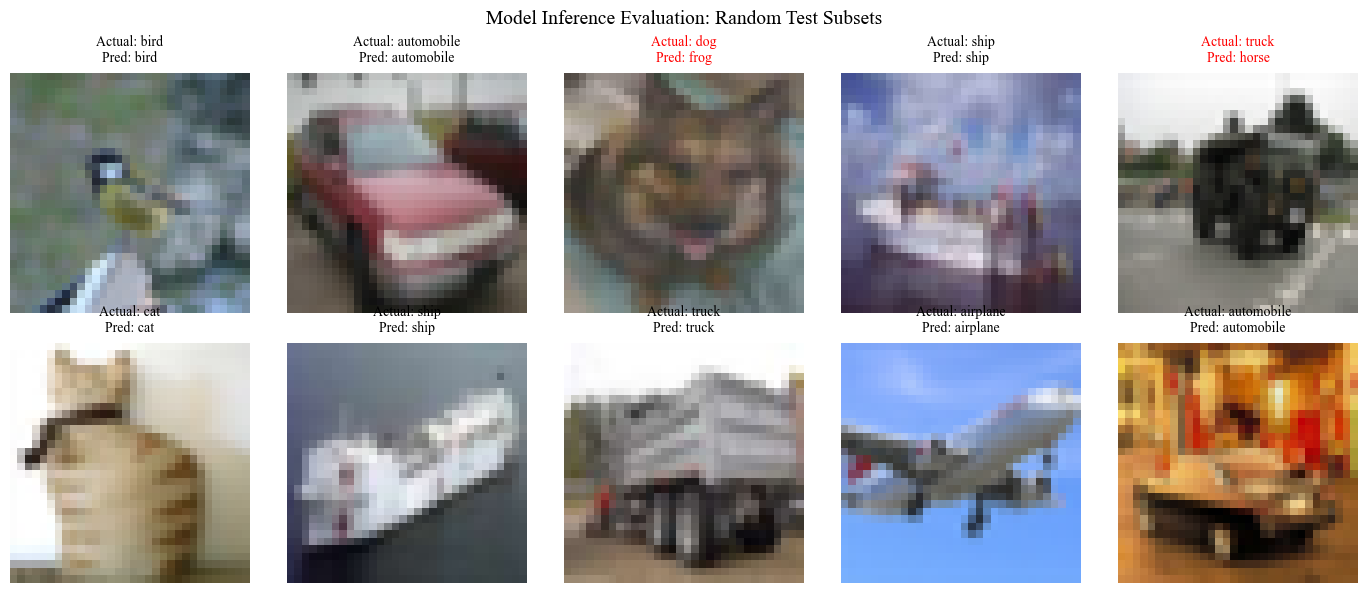

Saved Section 13 visualisation grid to 'cifar10_random_predictions.eps'


In [ ]:
import os
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm
import numpy as np

# 1. Configure custom Times New Roman font from the root directory
font_path = "/times.ttf"
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    prop = fm.FontProperties(fname=font_path)
    plt.rcParams["font.family"] = prop.get_name()
    plt.rcParams["font.weight"] = "bold"
    plt.rcParams["axes.titleweight"] = "bold"

class_names = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

# 2. Extract 10 random distinct indices from the test pool
np.random.seed(42) # Keeps selection consistent across runs
random_indices = np.random.choice(len(X_test), size=10, replace=False)

# 3. Initialize a 2x5 grid plot window
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes = axes.ravel()

for i, idx in enumerate(random_indices):
    img = X_test[idx]

    # Extract Ground Truth integer
    if len(y_test.shape) > 1 and y_test.shape[1] > 1:
        true_label_idx = np.argmax(y_test[idx]) # One-hot encoded format
    else:
        true_label_idx = int(y_test[idx])       # Sparse integer format

    true_name = class_names[true_label_idx]

    # Get Model Prediction
    pred_probs = model.predict(np.expand_dims(img, axis=0), verbose=0)
    pred_label_idx = np.argmax(pred_probs)
    pred_name = class_names[pred_label_idx]

    # 4. Display the image
    axes[i].imshow(img)
    axes[i].axis("off")

    # 5. Check accuracy to assign font coloring
    title_str = f"Actual: {true_name}\nPred: {pred_name}"

    if true_label_idx == pred_label_idx:
        title_color = "black"  # Correct predictions stay clean
    else:
        title_color = "red"    # Wrong predictions stand out in red

    axes[i].set_title(title_str, fontsize=10, fontweight="bold", color=title_color, pad=8)

plt.suptitle("Model Inference Evaluation: Random Test Subsets", fontsize=14, fontweight="bold", y=0.98)
plt.tight_layout()

# 6. Save final figure as a high-resolution Vector EPS standard at 600 DPI
plt.savefig("cifar10_random_predictions.eps", format="eps", dpi=600)
plt.show()
print("Saved Section 13 visualisation grid to 'cifar10_random_predictions.eps'")


In [ ]:
# implement the same in pytorch without using builtin methods